In [1]:
import duckdb
import geopandas as gpd

from srm import catalog
from srm.bcsd_config import BCSDConfig, PipelineOptions
from srm.pipeline import BCSDPipeline

In [2]:
# Define South Africa bounds
df = duckdb.sql(
    """
    install httpfs; load httpfs;
    install spatial; load spatial;
    SELECT name, ST_AsText(geom) as geometry
    FROM ST_Read('https://carbonplan-data.s3.us-west-2.amazonaws.com/countries-50m.json')
    WHERE NAME = 'South Africa'
    """
).df()
df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
south_africa_geom = gpd.GeoDataFrame(df, geometry="geometry")

# Set bounds with 2-degree buffer
lon_min, lat_min, lon_max, lat_max = south_africa_geom.total_bounds
bounds = [lat_min - 2, lat_max + 2, lon_min - 2, lon_max + 2]
bounds = [round(entry, 2) for entry in bounds]

print(f"South Africa subset bounds: {bounds}")

South Africa subset bounds: [np.float64(-48.96), np.float64(-20.15), np.float64(14.45), np.float64(39.89)]


In [3]:
# Operational settings (storage paths, environment, runtime flags).
# These live in PipelineOptions and do not affect the computation or cache key.
options = PipelineOptions(
    scratch_dir="s3://carbonplan-scratch/srm/bcsd-cache",
    output_dir="s3://carbonplan-scratch/srm/output",
    version="v6.0.1test002",
    environment="qa",
    verbose=True,
    apply_ocean_mask=False,
)

# Downscale DTR

In [4]:
# Run-identity configuration (affects computation and is hashed for cache invalidation).
config_dtr = BCSDConfig(
    gcm="CESM2-WACCM",
    variable="dtr",
    ensemble_member="007",  # NCAR-format label used in the SSP245 store
    scenario="SSP245",
    train_period_start=1978,
    train_period_end=2014,
    mapping_type="nonparametric",
    predict_period_start=2015,
    predict_period_end=2100,
    subset_bounds=tuple(bounds),
)

print(f"Run ID:      {config_dtr.run_id}")
print(f"Config hash: {config_dtr.config_hash}")
print(f"Detrend:     {config_dtr.detrend_data}")

Run ID:      CESM2-WACCM_dtr_007_SSP245_subset
Config hash: 254c3d422862
Detrend:     True


In [5]:
# Initialize pipeline
pipeline = BCSDPipeline(config_dtr, options)

# Run all three stages
print("Stage 1: Prepare observations (regrid ERA5 to GCM grid)")
obs_path = pipeline.prepare_observations(force=False)
print(f"✓ Observations cached at: {obs_path}\n")

print("Stage 2: Fit historical (debias and downscale historical period)")
hist_path = pipeline.fit_historical(force=False)
print(f"✓ Historical cached at: {hist_path}\n")

print("Stage 3: Transform scenario (debias and downscale future)")
scenario_path = pipeline.transform_scenario(force=False)
print(f"✓ Scenario output at: {scenario_path}")

Stage 1: Prepare observations (regrid ERA5 to GCM grid)
✓ Observations cached at: s3://carbonplan-scratch/srm/bcsd-cache/qa/v6.0.1test002/obs/CESM2-WACCM/dtr/lat-48.96to-20.15_lon14.45to39.89/obs_regridded.icechunk

Stage 2: Fit historical (debias and downscale historical period)
✓ Historical cached at: s3://carbonplan-scratch/srm/output/qa/v6.0.1test002/historical/CESM2-WACCM/dtr/001/lat-48.96to-20.15_lon14.45to39.89/d6bb98f7/historical.icechunk

Stage 3: Transform scenario (debias and downscale future)


/scratch/synced/src/srm/pipeline.py:243: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  result = xr.concat(
/opt/coiled/env/lib/python3.13/site-packages/ibicus/debias/_debiaser.py:532: UserWarning: cm_future contains inf or nan values. Not all debiasers support missing values and their presence might lead to infs or nans inside of the debiased values. Consider infilling the missing values.
  obs, cm_hist, cm_future = self._check_inputs_and_convert_if_possible(


✓ Scenario output at: s3://carbonplan-scratch/srm/output/qa/v6.0.1test002/ssp245/CESM2-WACCM/dtr/007/lat-48.96to-20.15_lon14.45to39.89/d6bb98f7/ssp245.icechunk


# Downscale tasmax

In [6]:
# Run-identity configuration (affects computation and is hashed for cache invalidation).
config_tasmax = BCSDConfig(
    gcm="CESM2-WACCM",
    variable="tasmax",
    ensemble_member="007",  # NCAR-format label used in the SSP245 store
    scenario="SSP245",
    mapping_type="nonparametric_hybrid",
    train_period_start=1978,
    train_period_end=2014,
    predict_period_start=2015,
    predict_period_end=2100,
    subset_bounds=tuple(bounds),
)

print(f"Run ID:      {config_tasmax.run_id}")
print(f"Config hash: {config_tasmax.config_hash}")
print(f"Detrend:     {config_tasmax.detrend_data}")

Run ID:      CESM2-WACCM_tasmax_007_SSP245_subset
Config hash: 20a1ee6eeb54
Detrend:     True


In [7]:
# Initialize pipeline
pipeline = BCSDPipeline(config_tasmax, options)

# Run all three stages
print("Stage 1: Prepare observations (regrid ERA5 to GCM grid)")
obs_path_tasmax = pipeline.prepare_observations(force=False)
print(f"✓ Observations cached at: {obs_path}\n")

print("Stage 2: Fit historical (debias and downscale historical period)")
hist_path_tasmax = pipeline.fit_historical(force=False)
print(f"✓ Historical cached at: {hist_path}\n")

print("Stage 3: Transform scenario (debias and downscale future)")
scenario_path_tasmax = pipeline.transform_scenario(force=False)
print(f"✓ Scenario output at: {scenario_path}")

Stage 1: Prepare observations (regrid ERA5 to GCM grid)
✓ Observations cached at: s3://carbonplan-scratch/srm/bcsd-cache/qa/v6.0.1test002/obs/CESM2-WACCM/dtr/lat-48.96to-20.15_lon14.45to39.89/obs_regridded.icechunk

Stage 2: Fit historical (debias and downscale historical period)


/opt/coiled/env/lib/python3.13/site-packages/ibicus/debias/_quantile_mapping.py:218: UserWarning: The default settings for variable tasmax in debiaser QuantileMapping are currently still experimental and may not have been evaluated in the peer-reviewed literature. Please review the results with care!
  return super()._from_variable(


✓ Historical cached at: s3://carbonplan-scratch/srm/output/qa/v6.0.1test002/historical/CESM2-WACCM/dtr/001/lat-48.96to-20.15_lon14.45to39.89/d6bb98f7/historical.icechunk

Stage 3: Transform scenario (debias and downscale future)


/scratch/synced/src/srm/pipeline.py:243: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  result = xr.concat(
/opt/coiled/env/lib/python3.13/site-packages/ibicus/debias/_quantile_mapping.py:218: UserWarning: The default settings for variable tasmax in debiaser QuantileMapping are currently still experimental and may not have been evaluated in the peer-reviewed literature. Please review the results with care!
  return super()._from_variable(
/opt/coiled/env/lib/python3.13/site-packages/ibicus/debias/_debiaser.py:532: UserWarning: cm_future contains inf or nan values. Not all debiasers support missing values and their presence might lead to infs or nans 

✓ Scenario output at: s3://carbonplan-scratch/srm/output/qa/v6.0.1test002/ssp245/CESM2-WACCM/dtr/007/lat-48.96to-20.15_lon14.45to39.89/d6bb98f7/ssp245.icechunk


# Downscale tasmin (alternative approach)

In [12]:
# Run-identity configuration (affects computation and is hashed for cache invalidation).
config_tasmax = BCSDConfig(
    gcm="CESM2-WACCM",
    variable="tasmin",
    ensemble_member="007",  # NCAR-format label used in the SSP245 store
    scenario="SSP245",
    mapping_type="nonparametric_hybrid",
    train_period_start=1978,
    train_period_end=2014,
    predict_period_start=2015,
    predict_period_end=2100,
    subset_bounds=tuple(bounds),
)

print(f"Run ID:      {config_tasmax.run_id}")
print(f"Config hash: {config_tasmax.config_hash}")
print(f"Detrend:     {config_tasmax.detrend_data}")

ValidationError: 1 validation error for BCSDConfig
variable
  Input should be 'tas', 'tasmax', 'pr', 'rsds' or 'dtr' [type=literal_error, input_value='tasmin', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/literal_error

In [ ]:
# Initialize pipeline
pipeline = BCSDPipeline(config_tasmax, options)

# Run all three stages
print("Stage 1: Prepare observations (regrid ERA5 to GCM grid)")
obs_path_tasmax = pipeline.prepare_observations(force=False)
print(f"✓ Observations cached at: {obs_path}\n")

print("Stage 2: Fit historical (debias and downscale historical period)")
hist_path_tasmax = pipeline.fit_historical(force=False)
print(f"✓ Historical cached at: {hist_path}\n")

print("Stage 3: Transform scenario (debias and downscale future)")
scenario_path_tasmax = pipeline.transform_scenario(force=False)
print(f"✓ Scenario output at: {scenario_path}")

# Compare outputs

In [8]:
from srm.analysis import load_cached_data

In [9]:
tasmax = load_cached_data(scenario_path_tasmax)["tasmax"]

In [10]:
dtr = load_cached_data(scenario_path)["dtr"]

In [17]:
tasmin = tasmax - dtr

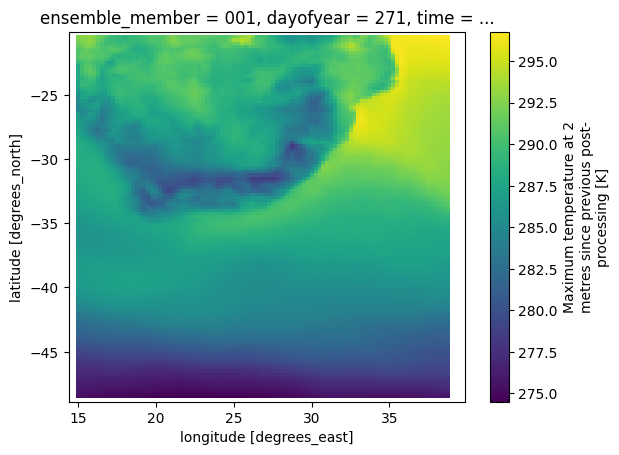

In [18]:
tasmin[1000, :, :].plot()

# Compare to coarse data

In [16]:
tasmax_coarse = catalog.get("CESM2-WACCM-SSP245-icechunk").to_xarray()["tasmax"]
tasmin_coarse = catalog.get("CESM2-WACCM-SSP245-icechunk").to_xarray()["tasmin"]

In [27]:
tasmin_subset = (
    tasmin_coarse.sel(ensemble_member="007").sel(lat=slice(-50, -20)).sel(lon=slice(15, 40))
)
tasmax_subset = (
    tasmax_coarse.sel(ensemble_member="007").sel(lat=slice(-50, -20)).sel(lon=slice(15, 40))
)

In [28]:
dtr_subset = tasmax_subset - tasmin_subset

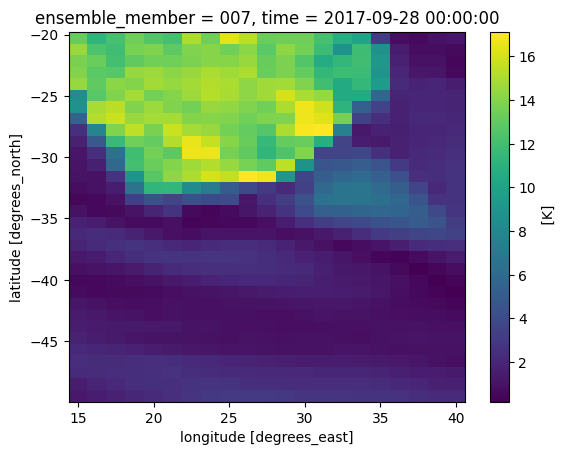

In [30]:
dtr_subset[1000, :, :].plot()

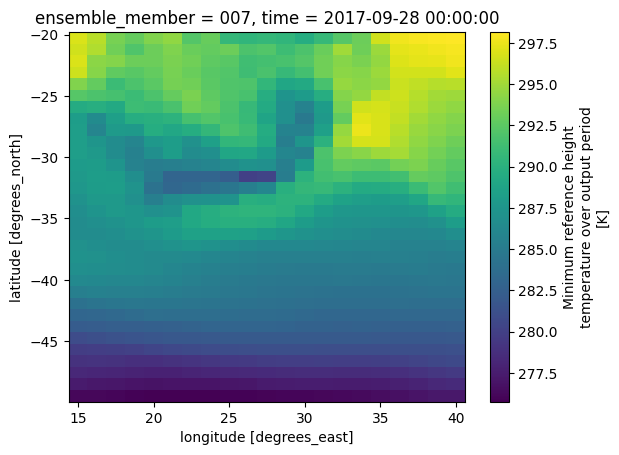

In [26]:
tasmin_subset[1000, :, :].plot()